<a href="https://colab.research.google.com/github/husthorng/Backpropagation_NN/blob/main/tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

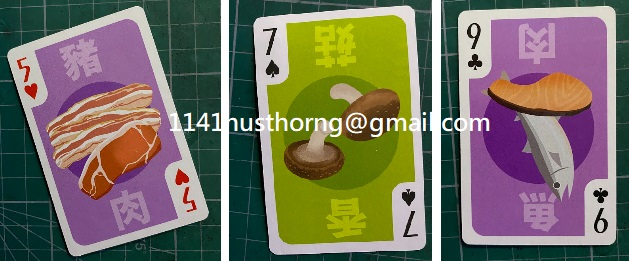

https://chatgpt.com/c/69b91d3e-e680-8321-8e21-5fa867595b1d

In [ ]:
#二、安裝套件
!pip install opencv-python
!pip install tensorflow

In [ ]:
#三、掛載 Google Drive
from google.colab import drive
drive.mount('/content/drive')
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#建立資料夾
import os

dataset_path = "/content/drive/MyDrive/AI_Vision_Dataset"

classes = ["class1","class2","class3"]

for c in classes:
    os.makedirs(dataset_path+"/"+c, exist_ok=True)

print("dataset folder ready")

dataset folder ready


In [ ]:
#四、WebCam拍照系統
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):

    js = Javascript('''
    async function takePhoto(quality) {

        const div = document.createElement('div');
        const capture = document.createElement('button');

        capture.textContent = 'Capture';

        div.appendChild(capture);

        const video = document.createElement('video');

        video.style.display = 'block';

        const stream = await navigator.mediaDevices.getUserMedia({video:true});

        document.body.appendChild(div);
        div.appendChild(video);

        video.srcObject = stream;

        await video.play();

        google.colab.output.setIframeHeight(document.documentElement.scrollHeight,true);

        await new Promise((resolve)=>capture.onclick=resolve);

        const canvas = document.createElement('canvas');

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;

        canvas.getContext('2d').drawImage(video,0,0);

        stream.getVideoTracks()[0].stop();

        div.remove();

        return canvas.toDataURL('image/jpeg',quality);

    }
    ''')

    display(js)

    data = eval_js('takePhoto({})'.format(quality))

    binary = b64decode(data.split(',')[1])

    with open(filename,'wb') as f:
        f.write(binary)

    return filename

In [ ]:
#五、拍照並存入 Dataset
import shutil

label = "class3"   # 修改類別

filename = take_photo()

save_path = dataset_path + "/" + label + "/" + filename

shutil.move(filename, save_path)

print("saved:", save_path)

<IPython.core.display.Javascript object>

saved: /content/drive/MyDrive/AI_Vision_Dataset/class3/photo.jpg


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/AI_Vision_Dataset"
#六、讀取 Dataset
import tensorflow as tf

img_size = 224
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size

)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size

)

Found 109 files belonging to 3 classes.
Using 88 files for training.
Found 109 files belonging to 3 classes.
Using 21 files for validation.


In [ ]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
#七、影像正規化
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y:(normalization_layer(x),y))

In [ ]:
#1 讀取 Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size

)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size,img_size),
    batch_size=batch_size

)

Found 109 files belonging to 3 classes.
Using 88 files for training.
Found 109 files belonging to 3 classes.
Using 21 files for validation.


In [ ]:
#2 先保存 class_names
class_names = train_ds.class_names

print(class_names)

['class1', 'class2', 'class3']


In [ ]:
#3 再做 normalization
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds = val_ds.map(lambda x,y:(normalization_layer(x),y))

In [ ]:
import tensorflow as tf #https://ithelp.ithome.com.tw/m/articles/10233758
from tensorflow.keras import layers, models
#4 建立 CNN
model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),

    layers.Dense(len(class_names),activation='softmax')

])


In [ ]:
#https://ithelp.ithome.com.tw/m/articles/10233758
#https://chih-sheng-huang821.medium.com/%E5%8D%B7%E7%A9%8D%E7%A5%9E%E7%B6%93%E7%B6%B2%E8%B7%AF-convolutional-neural-network-cnn-1-1%E5%8D%B7%E7%A9%8D%E8%A8%88%E7%AE%97%E5%9C%A8%E5%81%9A%E4%BB%80%E9%BA%BC-7d7ebfe34b8
model.compile(

    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,627 (37.49 MB)

 Trainable params: 9,826,627 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

W=model.weights
np.array(W[1]).shape

(32,)

In [ ]:
#九、訓練 AI
epochs = 20

history = model.fit(

    train_ds,
    validation_data=val_ds,
    epochs=epochs

)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 0.3864 - loss: 2.0341 - val_accuracy: 0.3810 - val_loss: 0.9079
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.3409 - loss: 1.0163 - val_accuracy: 0.9048 - val_loss: 0.7115
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 5s/step - accuracy: 0.6591 - loss: 0.6990 - val_accuracy: 0.9048 - val_loss: 0.3981
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 6s/step - accuracy: 0.7955 - loss: 0.4744 - val_accuracy: 0.6190 - val_loss: 0.4392
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.8523 - loss: 0.3110 - val_accuracy: 0.9048 - val_loss: 0.4532
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.8068 - loss: 0.7683 - val_accuracy: 0.7619 - val_loss: 0.7250
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.8864 - loss: 0.3497 - val_accuracy: 1.0000 - val_loss: 0.1626
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.9773 - loss: 0.1811 - val_accuracy: 0.9048 - val_loss: 0.2029
Epoch 9

In [ ]:
#十、儲存模型
model.save("/content/drive/MyDrive/AI_Vision_Model")

ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=/content/drive/MyDrive/AI_Vision_Model.

In [ ]:
model.save("/content/drive/MyDrive/AI_Vision_Model.keras")
model.save("/content/drive/MyDrive/AI_Vision_ModelB.keras")

In [ ]:
#之後讀取模型
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/AI_Vision_Dataset/AI_Vision_ModelB.keras")

In [ ]:
#五、拍照並存入 Dataset
import shutil

label = "class1"   # 修改類別

filename = take_photo()

save_path = dataset_path + "/" + label + "/" + filename

shutil.move(filename, save_path)

print("saved:", save_path)

<IPython.core.display.Javascript object>

saved: /content/drive/MyDrive/AI_Vision_Dataset/class1/photo.jpg


In [ ]:
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# 載入模型
model = load_model("/content/drive/MyDrive/AI_Vision_Dataset/AI_Vision_ModelB.keras")

# class names（一定要跟訓練一致）
class_names = ['5紅心 豬肉','7黑桃 香菇','9梅花 魚肉']  # ⚠️請改成你的

# 讀圖
img = cv2.imread("/content/drive/MyDrive/AI_Vision_Dataset/class1/IMG_0028.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 🔥關鍵

img = cv2.resize(img,(224,224))
img = img / 255.0
img = np.expand_dims(img,0)

# 預測
pred = model.predict(img)
pred_class = np.argmax(pred)

print("prediction:", pred)
print("預測類別:", class_names[pred_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
prediction: [[9.9997401e-01 5.0268798e-09 2.5942976e-05]]
預測類別: 5紅心 豬肉


In [ ]:
pred[0][0]

np.float32(1.8066378e-10)

In [ ]:
save_path

'/content/drive/MyDrive/AI_Vision_Dataset/class1/photo.jpg'